# Анализ сложных данных

Под анализом сложных данных чаще всего понимаются задачи по обработке текста и изображений. Примерами таких задач являются:

- Обработка естественного языка (NLP).

- Машинный перевод.

- Чат-боты и диалоговые системы.

- Генерация текстов.

- Проверка орфографии и грамматики.

- Классификация и кластеризация текстов.

- Извлечение информации.

В данном практикуме мы рассмотрим методы **предварительной обработки текстов** (Bag-of-Words (Counter), TF-IDF, Word2Vec и Doc2Vec, языковые эмбеддинги),
а также методы **обработки изображений**.

#### План занятия:

1. Предобработка текстов

    - CountVectorizer

    - TF-IDF

    - Токенизация и разбор предложения

    - Пример задачи: распознавание спама среди электронных писем

    - Обучение логистической регрессии на TF-IDF

2. Байесовская классификация

3. Работа с изображениями

## 1. Предобработка текстов

Предобработка текстов — ключевой этап в задачах анализа естественного языка. Он включает в себя:

- преобразование **неструктурированных текстовых данных в числовое представление**, пригодное для машинного обучения;

- применение методов токенизации, а также синтаксического и семантического разбора предложений;

Это позволяет выделить значимые элементы и учесть структуру языка.

### CountVectorizer

**CountVectorizer** — это метод, который преобразует коллекцию текстов в **матрицу частот слов**.

- CountVectorizer токенизирует входные данные и строит словарь известных слов, а затем представляет документ, используя этот словарь.

- Из корпуса текстов получается разреженная матрица чисел вхождений.

&emsp;

Алгоритм работы:

1. Строится словарь всех уникальных слов во всех документах.

2. Для каждого документа создаётся вектор, где на позиции каждого слова из словаря указывается, сколько раз это слово встречается в документе.

&emsp;

Пусть $D = \{d_1, d_2, ..., d_N\}$ - набор документов, $V = \{w_1, w_2, ..., w_M\}$ - словарь (все уникальные слова). Тогда для документа $d_i$ и слова $w_j$:

- $Count(d_i, w_j) =$ количество вхождений слова $w_j$ в документе $d_i$ - представляет собой матрицу $X$ размера $N \times M$.

- $X_{ij} = Count(d_i, w_j)$

Воспользуемся методом на практике. Зададим корпус из 4х текстов.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

corpus = [
     'This is the first document.',
     'This document is the second document.',
     'And this is the third one.',
     'Is this the first document?',]

Выведем названия признаков.

Будем ипользовать метод __get_feature_names_out__ для получения списка имен признаков (слов или токенов), которые были извлечены из текста в процессе обучения CountVectorizer.

Он возвращает массив (список слов), где каждый элемент — это слово (или n-грамма) из словаря, созданного векторизатором.

In [ ]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(corpus)
print(vectorizer.get_feature_names_out())
print(X.toarray())

['and' 'document' 'first' 'is' 'one' 'second' 'the' 'third' 'this']
[[0 1 1 1 0 0 1 0 1]
 [0 2 0 1 0 1 1 0 1]
 [1 0 0 1 1 0 1 1 1]
 [0 1 1 1 0 0 1 0 1]]


Итоговый объект будет представлять собой разреженную матрицу.

In [ ]:
X

<4x9 sparse matrix of type '<class 'numpy.int64'>'
	with 21 stored elements in Compressed Sparse Row format>

In [ ]:
import pandas as pd
pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())

,and,document,first,is,one,second,the,third,this
0,0,1,1,1,0,0,1,0,1
1,0,2,0,1,0,1,1,0,1
2,1,0,0,1,1,0,1,1,1
3,0,1,1,1,0,0,1,0,1


__n-грамма__ — это последовательность из $N$ соседних элементов (слов, букв или символов), выделенная из текста.

In [ ]:
vectorizer2 = CountVectorizer(analyzer='word', ngram_range=(1, 3))
X2 = vectorizer2.fit_transform(corpus)
print(vectorizer2.get_feature_names_out())
print(X2.toarray())

['and' 'and this' 'and this is' 'document' 'document is' 'document is the'
 'first' 'first document' 'is' 'is the' 'is the first' 'is the second'
 'is the third' 'is this' 'is this the' 'one' 'second' 'second document'
 'the' 'the first' 'the first document' 'the second' 'the second document'
 'the third' 'the third one' 'third' 'third one' 'this' 'this document'
 'this document is' 'this is' 'this is the' 'this the' 'this the first']
[[0 0 0 1 0 0 1 1 1 1 1 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 1 0 0 1 1 0 0]
 [0 0 0 2 1 1 0 0 1 1 0 1 0 0 0 0 1 1 1 0 0 1 1 0 0 0 0 1 1 1 0 0 0 0]
 [1 1 1 0 0 0 0 0 1 1 0 0 1 0 0 1 0 0 1 0 0 0 0 1 1 1 1 1 0 0 1 1 0 0]
 [0 0 0 1 0 0 1 1 1 0 0 0 0 1 1 0 0 0 1 1 1 0 0 0 0 0 0 1 0 0 0 0 1 1]]


Добавим n-граммы в качестве признаков в датафрейм.

In [ ]:
pd.DataFrame(X2.toarray(), columns=vectorizer2.get_feature_names_out())

,and,and this,and this is,document,document is,document is the,first,first document,is,is the,...,the third one,third,third one,this,this document,this document is,this is,this is the,this the,this the first
0,0,0,0,1,0,0,1,1,1,1,...,0,0,0,1,0,0,1,1,0,0
1,0,0,0,2,1,1,0,0,1,1,...,0,0,0,1,1,1,0,0,0,0
2,1,1,1,0,0,0,0,0,1,1,...,1,1,1,1,0,0,1,1,0,0
3,0,0,0,1,0,0,1,1,1,0,...,0,0,0,1,0,0,0,0,1,1


## TF-IDF

TF-IDF — это способ взвешивания слов, который учитывает не только частоту слова в документе, но и его важность относительно всей коллекции.

&emsp;

**TF (Term Freqency)** - частота слова в документе:

- $TF(d,w) = \dfrac{\text{частота вхождений слова w в документе d}}{\text{общее число слов в документе d}}$

&emsp;

**IDF (Inverse Document Freqency)** - обратная частота документов:

- $IDF(w) = log(\dfrac{N}{1 + df(w)})$, где

- N - общее число документов,

- $df(w)$ - число документов, в которых встречается слово $w$.

&emsp;

**TF-IDF**:

- $TF-IDF(d,w) = TF(d,w) \times IDF(w)$

&emsp;

Тем самым, часто встречающиеся слова в одном документе получают больший вес, а слова, встречающиеся почти во всех документах, получают меньший вес (например, «и», «в», «на»).

Реализуем на нашем корпусе текстов.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(corpus)
print(vectorizer.get_feature_names_out())
print(X)

['and' 'document' 'first' 'is' 'one' 'second' 'the' 'third' 'this']
  (0, 1)	0.46979138557992045
  (0, 2)	0.5802858236844359
  (0, 6)	0.38408524091481483
  (0, 3)	0.38408524091481483
  (0, 8)	0.38408524091481483
  (1, 5)	0.5386476208856763
  (1, 1)	0.6876235979836938
  (1, 6)	0.281088674033753
  (1, 3)	0.281088674033753
  (1, 8)	0.281088674033753
  (2, 4)	0.511848512707169
  (2, 7)	0.511848512707169
  (2, 0)	0.511848512707169
  (2, 6)	0.267103787642168
  (2, 3)	0.267103787642168
  (2, 8)	0.267103787642168
  (3, 1)	0.46979138557992045
  (3, 2)	0.5802858236844359
  (3, 6)	0.38408524091481483
  (3, 3)	0.38408524091481483
  (3, 8)	0.38408524091481483


Выыведем IDF - обратные частоты документов.

In [ ]:
vectorizer.idf_

array([1.91629073, 1.22314355, 1.51082562, 1.        , 1.91629073,
       1.91629073, 1.        , 1.91629073, 1.        ])

In [ ]:
X

<4x9 sparse matrix of type '<class 'numpy.float64'>'
	with 21 stored elements in Compressed Sparse Row format>

In [ ]:
pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())

,and,document,first,is,one,second,the,third,this
0,0.000000,0.469791,0.580286,0.384085,0.000000,0.000000,0.384085,0.000000,0.384085
1,0.000000,0.687624,0.000000,0.281089,0.000000,0.538648,0.281089,0.000000,0.281089
2,0.511849,0.000000,0.000000,0.267104,0.511849,0.000000,0.267104,0.511849,0.267104
3,0.000000,0.469791,0.580286,0.384085,0.000000,0.000000,0.384085,0.000000,0.384085


## Токенизация и разбор предложения

**Токенизация** — это процесс разбиения текста на отдельные элементы, называемые токенами.

Обычно токенами выступают слова, но могут быть и фразы, символы или даже предложения. В предложении _«Машинное обучение — это круто!»_ будут выделены следующие токены:

[«машинное», «обучение», «это», «круто»].

&emsp;

Токенизация может включать:

- разделение по пробелам и знакам препинания;
- приведение к нижнему регистру;
- удаление стоп-слов (частых, но неинформативных слов: «и», «в», «на» и т. д.).

&emsp;

Natural Language Toolkit (__NLTK__) - ведущая библиотека Python для обработки естественного языка.

Загрузим токенизатор Punkt для разделения текста на отдельные предложения и слова, а также стоп-слова, которые будем удалять.

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
from nltk.tokenize import sent_tokenize
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

Токенизируем текст.

In [ ]:
text = """Backgammon is one of the oldest known board games.
Its history can be traced back nearly 5,000 years to archeological discoveries in the Middle East.
It is a two player game where each player has fifteen checkers which move between twenty-four points according to the roll of two dice."""

sentences = sent_tokenize(text)
for sentence in sentences:
    tokens = word_tokenize(sentence)
    print(tokens)

['Backgammon', 'is', 'one', 'of', 'the', 'oldest', 'known', 'board', 'games', '.']
['Its', 'history', 'can', 'be', 'traced', 'back', 'nearly', '5,000', 'years', 'to', 'archeological', 'discoveries', 'in', 'the', 'Middle', 'East', '.']
['It', 'is', 'a', 'two', 'player', 'game', 'where', 'each', 'player', 'has', 'fifteen', 'checkers', 'which', 'move', 'between', 'twenty-four', 'points', 'according', 'to', 'the', 'roll', 'of', 'two', 'dice', '.']


In [ ]:
sentences

['Backgammon is one of the oldest known board games.',
 'Its history can be traced back nearly 5,000 years to archeological discoveries in the Middle East.',
 'It is a two player game where each player has fifteen checkers which move between twenty-four points according to the roll of two dice.']

__Pymorphy__ - библиотека для морфологического анализа русского языка на Python.

https://github.com/pymorphy2/pymorphy2

In [ ]:
!pip install pymorphy2

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 38.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13707 sha256=b65f5b09811e20da5014fc263c96a41efd686faaab58288f44507f107e835e51
  Stored in directory: /root/.cache/pip/wheels/fc/ab/d4/5da2067ac95b36618c629a5f93f809425700506f72c9732fac
Successfully built docopt


Выведем токены для каждого предложения.

In [ ]:
import pymorphy2
import re
morph = pymorphy2.MorphAnalyzer()
stop_words = stopwords.words('russian')

text = """Обработка текстов на естественном языке — общее направление искусственного интеллекта и математической лингвистики.
Оно изучает проблемы компьютерного анализа и синтеза текстов на естественных языках.
Применительно к искусственному интеллекту анализ означает понимание языка, а синтез — генерацию грамотного текста."""

sentences = nltk.sent_tokenize(text, language="russian")

for sentence in sentences:
    print('___________________')
    print(sentence)
    sentence_ = re.sub(r"[^А-Яа-яёЁ ]", "", sentence)
    print(sentence_)
    tokens = nltk.word_tokenize(sentence_)
    print(tokens)
    tokens = [i for i in tokens if (i not in stop_words)]
    print(tokens)
    tokens = [morph.parse(i)[0].normal_form for i in tokens]
    print(tokens)

___________________
Обработка текстов на естественном языке — общее направление искусственного интеллекта и математической лингвистики.
Обработка текстов на естественном языке  общее направление искусственного интеллекта и математической лингвистики
['Обработка', 'текстов', 'на', 'естественном', 'языке', 'общее', 'направление', 'искусственного', 'интеллекта', 'и', 'математической', 'лингвистики']
['Обработка', 'текстов', 'естественном', 'языке', 'общее', 'направление', 'искусственного', 'интеллекта', 'математической', 'лингвистики']
['обработка', 'текст', 'естественный', 'язык', 'общий', 'направление', 'искусственный', 'интеллект', 'математический', 'лингвистика']
___________________
Оно изучает проблемы компьютерного анализа и синтеза текстов на естественных языках.
Оно изучает проблемы компьютерного анализа и синтеза текстов на естественных языках
['Оно', 'изучает', 'проблемы', 'компьютерного', 'анализа', 'и', 'синтеза', 'текстов', 'на', 'естественных', 'языках']
['Оно', 'изучает', '

## Распознавание спама


Загрузим данные и разархивируем.

In [ ]:
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip

--2023-06-15 16:23:40--  https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘smsspamcollection.zip’

smsspamcollection.z     [ <=>                ] 198.65K  1.02MB/s    in 0.2s    

2023-06-15 16:23:40 (1.02 MB/s) - ‘smsspamcollection.zip’ saved [203415]



In [ ]:
!unzip smsspamcollection.zip

Archive:  smsspamcollection.zip
  inflating: SMSSpamCollection       
  inflating: readme                  


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_table('SMSSpamCollection', sep='\t', header=None, names=['label','sms_message'])

In [ ]:
df.head()

,label,sms_message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df.shape

(5572, 2)

## Логистическая регрессия + TF-IDF

Для распознавания спама с помощью логистической регрессии и TF-IDF реализуем следующий алгоритм:

1. Токенизируем письма и произведем предобработку.

2. Преобразуем письма в числовые векторы с помощью TF-IDF.

3. Обучим логистическую регрессию на этих признаках.

4. Модель классифицирует новые письма как «спам» или «не спам» по вероятности принадлежности к одному из классов (0 или 1).

In [ ]:
vectorizer = TfidfVectorizer()
vectorizer.fit(df['sms_message'].tolist())

TfidfVectorizer()

In [ ]:
df['sms_message']

0       Go until jurong point, crazy.. Available only ...
1                           Ok lar... Joking wif u oni...
2       Free entry in 2 a wkly comp to win FA Cup fina...
3       U dun say so early hor... U c already then say...
4       Nah I don't think he goes to usf, he lives aro...
                              ...                        
5567    This is the 2nd time we have tried 2 contact u...
5568                 Will ü b going to esplanade fr home?
5569    Pity, * was in mood for that. So...any other s...
5570    The guy did some bitching but I acted like i'd...
5571                           Rofl. Its true to its name
Name: sms_message, Length: 5572, dtype: object

In [ ]:
vectorizer.transform(['The guy did some bitching but I acted like'])

<1x8713 sparse matrix of type '<class 'numpy.float64'>'
	with 8 stored elements in Compressed Sparse Row format>

In [ ]:
res_tfidf = vectorizer.transform(df['sms_message'].tolist())
res_tfidf

<5572x8713 sparse matrix of type '<class 'numpy.float64'>'
	with 74169 stored elements in Compressed Sparse Row format>

Разреженные матрицы хранят только ненулевые значения для экономии памяти.

Метод __.todense()__ заполняет все нулевые позиции и возвращает полную матрицу типа numpy.matrix, где хранятся абсолютно все элементы, включая нули — то есть в обычный массив NumPy.

In [ ]:
res_tfidf[0].todense()

matrix([[0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import LabelEncoder

Обучим кодировщик LabelEncoder.

In [ ]:
le = LabelEncoder().fit(df['label'])

In [ ]:
df['cat_label'] = le.transform(df['label'])

In [ ]:
df['cat_label'].value_counts()

0    4825
1     747
Name: cat_label, dtype: int64

In [ ]:
X_tr, X_ts, y_tr, y_ts = train_test_split(res_tfidf, df['cat_label'], test_size=0.2, random_state=1)

Обучим логистическую регрессию и предскажем классы.

In [ ]:
lr = LogisticRegression().fit(X_tr, y_tr)

In [ ]:
y_pred = lr.predict(X_ts)
f1_score(y_ts, y_pred)

0.8659003831417624

In [ ]:
print(classification_report(y_ts, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       968
           1       0.99      0.77      0.87       147

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.97      1115



## 2. Байесовская классификация

__Теорема Байеса__ позволяет пересчитать вероятность гипотезы $H$ при наступлении события $A$:

$P(A|B) = \dfrac{P(B|A)P(A)}{P(B)}$, где:

- $P(A|B)$ — апостериорная вероятность события A при условии выполнения события B (от лат. «aposteriori» — последующая, свершившаяся);

- $P(B|A)$ — условная вероятность события B при условии выполнения события A;

- $P(A)$ и $P(B)$ — априорные вероятности событий A и B соответственно.

&emsp;

__Наивный байесовский классификатор__ - это вероятностный алгоритм классификации, основанный на применении теоремы Байеса со строгим («наивным») предположением о независимости признаков между собой при заданном классе.

- В задачах машинного обучения, где нужно классифицировать объект по набору признаков $(x_1, x_2, ..., x_n)$, классическая формула Байеса становится трудновычислимой, так как требует знать совместную вероятность всех признаков $P(x_1, ..., x_n | A)$.

- Чтобы упростить расчеты, используется допущение о __«наивной» условной независимости__.

- Это допущение сильно упрощает задачу классификации, поскольку оцениваются одномерные вероятностные плотности вместо одной одномерной.

&emsp;

Почему Наивный Байесовский классификатор выбирает класс с __максимальной апостериорной вероятностью__?

$\rightarrow$ при наличии дополнительной информации мы с большой долей уверенности можем предположить, что это объект относится к классу $X$, чем в случае, если эта информация отсутствует, т.е. ее можно определить только после того, как мы узнаем признаки объекта.

Обучим Байесовский класификатор. Поделим данные на обучающую и тестовую выборки.

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df['sms_message'], df['cat_label'], random_state=1)

Посчитаем количество слов в предложениях. Получим матрицу размерности (количество предложений Х размер словаря).

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

count_vector = CountVectorizer(max_features=1000)
train_tensor = count_vector.fit_transform(X_train).toarray().astype('float')
test_tensor = count_vector.transform(X_test).toarray().astype('float')

Посмотрим на размер обучающей выборки.

In [ ]:
train_tensor.shape

(4179, 1000)

Выведем суммарное количество слов в предложениях.

In [ ]:
train_tensor.sum()

47637.0

In [ ]:
pd.DataFrame(train_tensor, columns=count_vector.get_feature_names_out())

,000,04,0800,08000839402,08000930705,10,100,1000,10p,11,...,yes,yesterday,yet,yo,you,your,yours,yourself,yr,yup
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4174,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4175,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4176,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4177,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# тензор с предложениями класса spam
spam_train_tensor = train_tensor[(y_train == 1).values]

# тензор с предложениями класса not_spam
not_spam_train_tensor = train_tensor[(y_train == 0).values]

In [ ]:
spam_train_tensor.sum()

9857.0

In [ ]:
not_spam_train_tensor.sum()

37780.0

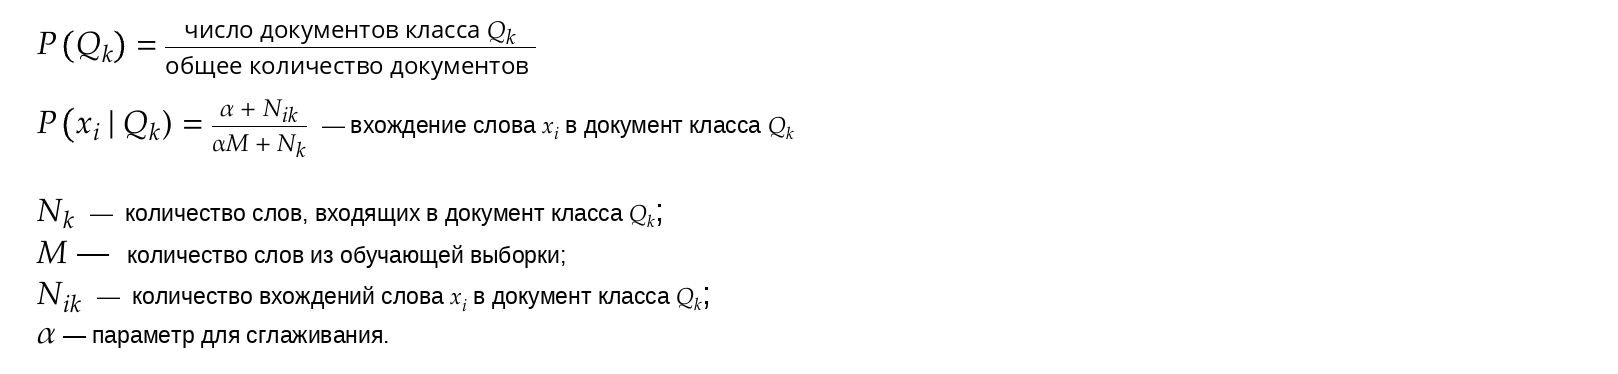

Выведем вероятности слова при условии, что предложение 1) является спамом и 2) не является спамом.

Добавление единицы (+1) — сглаживание Лапласа, предотвращающее нулевую вероятность редких слов.

In [ ]:
# вероятность того, что слово принадлежит классу 1 - «спам»
p_w_spam = (spam_train_tensor.sum(axis=0) + 1) / (train_tensor.shape[0] + spam_train_tensor.sum())

# вероятность того, что слово принадлежит классу 0 - «не спам».
p_w_not_spam = (not_spam_train_tensor.sum(axis=0) + 1) / (train_tensor.shape[0] + not_spam_train_tensor.sum())

In [ ]:
p_w_spam[:10], p_w_not_spam[:10]

(array([0.00170989, 0.00071245, 0.0007837 , 0.0007837 , 0.00085494,
        0.00142491, 0.00213736, 0.00227985, 0.00149615, 0.00085494]),
 array([2.38327892e-05, 2.38327892e-05, 2.38327892e-05, 2.38327892e-05,
        2.38327892e-05, 2.14495102e-04, 4.76655783e-05, 2.38327892e-05,
        2.38327892e-05, 7.14983675e-05]))

Проверим на одном письме.

In [ ]:
test_sample = test_tensor[0]
test_sample

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

Сравним суммы произведений вероятностей.

In [ ]:
(test_sample * p_w_spam).sum()

0.013465374750641208

In [ ]:
(test_sample * p_w_not_spam).sum()

0.023308467789985462

Мы видим, что значение вероятности против спама (p_w_not_spam) выше, чем значение за спам (p_w_spam).

Поскольку второе значение больше первого, делаем вывод, что данное письмо скорее относится к классу «не спам».

Теперь посчитаем значения для всей тестовой выборки.

In [ ]:
test_tensor.shape

(1393, 1000)

Посчитаем предсказания как сравнение величин за спам и против спама.

In [ ]:
y_pred = (test_tensor*p_w_spam).sum(axis=1) >= (test_tensor*p_w_not_spam).sum(axis=1)

Выведем предсказанные значения.

In [ ]:
y_pred.astype(int)

array([0, 0, 0, ..., 0, 1, 0])

На тестовой выборке посмотрим истинные значения.

In [ ]:
y_test.to_numpy()

array([0, 0, 0, ..., 0, 1, 0])

Сравним реальные метрики с предсказанными.

In [ ]:
test = (y_pred.astype(int) == y_test.to_numpy())

Посчитаем точность модели как отношение количества совпадений к размеру выборки.

In [ ]:
test.sum().item() / test.shape[0]

0.9016511127063891

In [ ]:
print(classification_report(y_test.to_numpy(), y_pred.astype(int)))

              precision    recall  f1-score   support

           0       0.97      0.91      0.94      1208
           1       0.59      0.83      0.69       185

    accuracy                           0.90      1393
   macro avg       0.78      0.87      0.82      1393
weighted avg       0.92      0.90      0.91      1393



## 3. Работа с изображениями

При работе с изображениями (Computer Vision) мы сталкиваемся с рядом специфических проблем:

- __Высокая размерность__: каждое изображение представляет собой матрицу пикселей, что создаёт огромное пространство признаков.

- __Коррелированные признаки__: соседние пиксели обычно имеют схожие значения, что увеличивает избыточность данных.

- __Нелинейные зависимости__: пространственное расположение пикселей порождает нелинейные взаимосвязи, усложняя анализ.

- Необходимость __снижения размерности данных__: экономия ресурсов, устранение шума, упрощение интерпретации.

Для снижения размерности в аналитике используется метод главных компонент (PCA - Principal Component Analysis).

&emsp;

__Метод главных компонент (PCA)__ — это линейный метод сокращения размерности, который находит ортогональный базис, вдоль которого дисперсия данных максимальна.

Основная идея:

- Найти оси, вдоль которых данные варьируются сильнее всего.

- Проецировать данные на эти оси, отбрасывая менее значимые компоненты.

&emsp;

Алгоритм работы:

Пусть имеется набор данных $X$, состоящий из $n$ наблюдений, каждое из которых представлено $d$-мерным вектором.

1. __Центрирование данных__:

     - $X_{centered} = X - \bar{x}$,

       где $\bar{x}$ — среднее значение по каждому измерению.

2. Нахождение __ковариационной марицы__:

     - $C = \dfrac{1}{n - 1}X^{T}_{centered}X_{centered}$

3. Поиск __собственных векторов и значений__:

     - $C \times v_{i} = \lambda_{i} \times v_{i}$

       Собственные векторы $v_{i}$, упорядоченные по убыванию собственных значений $\lambda_{i}$, образуют __главные компоненты__.

4. Выбор первых $k$ __главных компонент__:

     - $Z = X_{centered} \times [v_1, ..., v_k]$

       $Z$ — новая матрица пониженной размерности.





Реализуем на практике.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn.datasets
from sklearn.decomposition import PCA

Загрузим датасет и нормируем данные.

In [ ]:
mnist = sklearn.datasets.fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist['data'], mnist['target']

X = X.astype(float) / 255.0
X

/Library/Python/3.9/site-packages/sklearn/datasets/_openml.py:1022: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

Применим PCA. Сохраним 95% дисперсии, задав параметр **n_components**=0.95.

На этапе fit() модель PCA изучает структуру данных и находит оптимальные направления (главные компоненты), вдоль которых данные обладают наибольшей дисперсией:

Этапы работы:

- Централизация данных.

- Расчет ковариационной матрицы данных.

- Нахождение собственных векторов и собственных значений ковариационной матрицы.

- Выбор главных компонент (собственных векторов с наибольшими собственными значениями).

&emsp;

На этапе transform() данные проецируются на выбранные главные компоненты, уменьшая их размерность.

Новая матрица получается путем умножения центрированных данных на матрицу главных компонент.


In [ ]:
pca = PCA(n_components=0.95)
X_reduced = pca.fit_transform(X)
X_reduced

array([[ 0.47943237, -1.24013272, -0.20051698, ...,  0.13614523,
        -0.05578728,  0.08385381],
       [ 3.96272158, -1.13711224,  2.25929704, ...,  0.09364252,
        -0.02565818, -0.09765794],
       [-0.23135666,  1.54391155, -0.635287  , ..., -0.0210307 ,
         0.21568709, -0.37934891],
       ...,
       [-1.06473339,  2.31403333,  1.33870145, ..., -0.17159665,
         0.1403222 ,  0.1959456 ],
       [-1.21656793, -0.45775353,  2.4930196 , ..., -0.08573903,
         0.08000599, -0.16738343],
       [ 4.15240049, -0.32702956,  2.86800856, ...,  0.16167977,
        -0.07863556, -0.19577889]])

Построим график накопленной дисперсии.

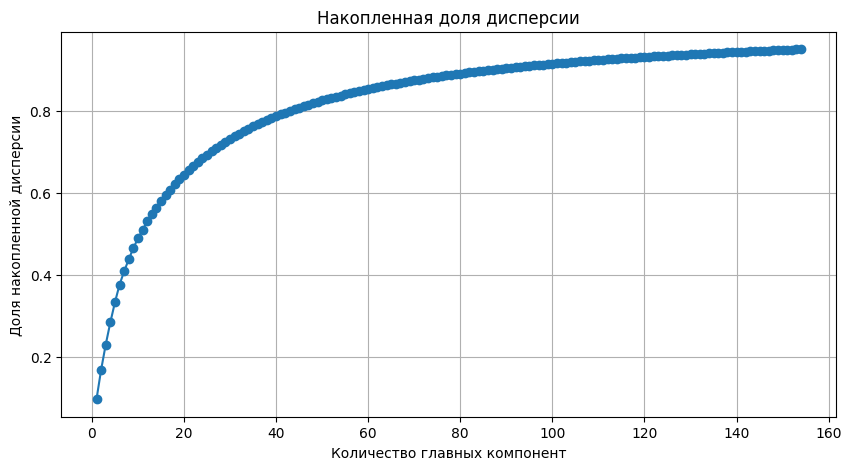

In [ ]:
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumulative_explained_variance)+1), cumulative_explained_variance, marker='o')
plt.xlabel('Количество главных компонент')
plt.ylabel('Доля накопленной дисперсии')
plt.title('Накопленная доля дисперсии')
plt.grid(True)
plt.show()

Определим функцию отображения сравнения изображений.

In [ ]:
def reconstruct_image(pca, reduced_data, index):
    original_image = X[index].reshape(28, 28)

    # Восстанавливаем изображение
    reconstructed_data = pca.inverse_transform(reduced_data[index])
    reconstructed_image = reconstructed_data.reshape(28, 28)

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(original_image, cmap='gray')
    ax[0].set_title('Оригинальное изображение')
    ax[1].imshow(reconstructed_image, cmap='gray')
    ax[1].set_title(f'Восстановленное изображение ({pca.n_components_} компонент)')
    plt.show()

Протестируем восстановление.

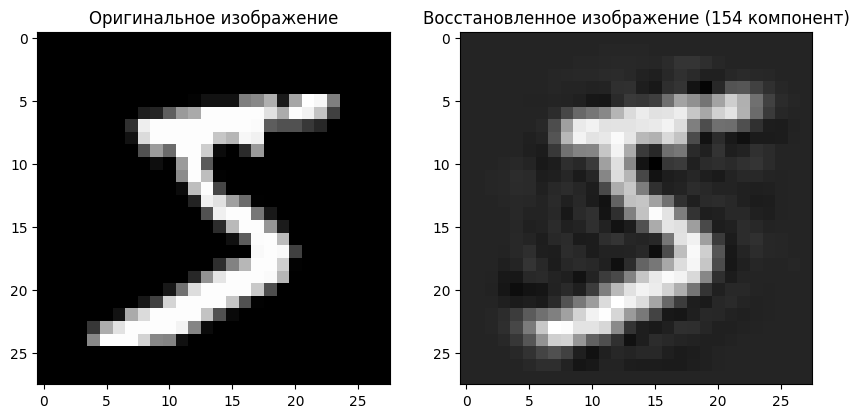

In [ ]:
reconstruct_image(pca, X_reduced, 0)